**LangChain Agent Executor**

In this chapter, we will continue from the introduction to agents and dive deeper into agents. Learning how to build our custom agent execution loop for v0.3 of LangChain.

Importing the libraries

In [1]:
import langchain_core
import langchain_community
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model="llama3.1",
    temperature=0
)

c:\Users\PatelDharmikkumar\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


What is the Agent Executor?

When we talk about agents, a significant part of an "agent" is simple code logic, iteratively rerunning LLM calls and processing their output. The exact logic varies significantly, but one well-known example is the ReAct agent.

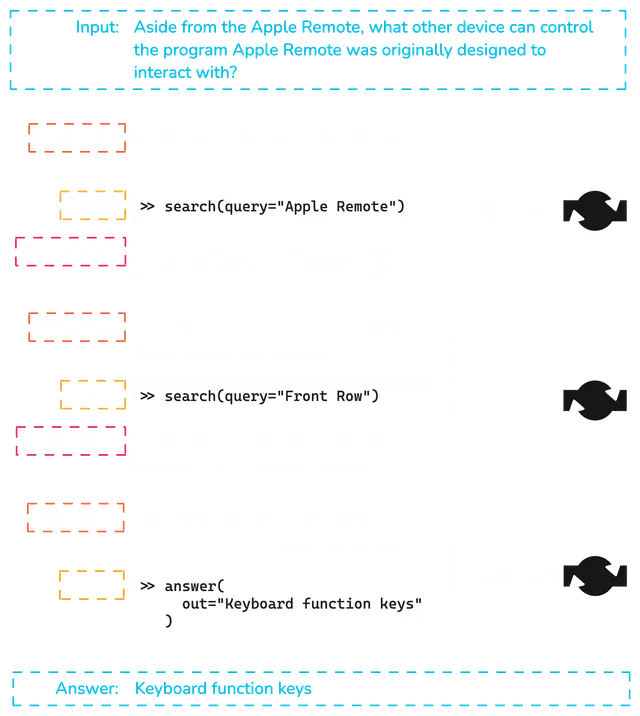

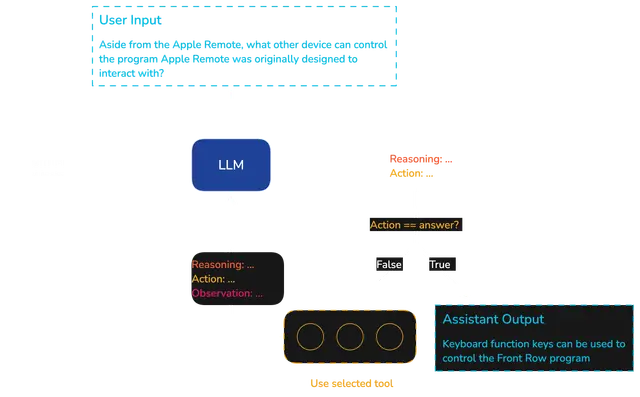

Reason + Action (ReAct) agents use iterative reasoning and action steps to incorporate chain-of-thought and tool-use into their execution. During the reasoning step, the LLM generates the steps to take to answer the query. Next, the LLM generates the action input, which our code logic parses into a tool call.

Following our action step, we get an observation from the tool call. Then, we feed the observation back into the agent executor logic for a final answer or further reasoning and action steps.

The agent and agent executor we will be building will follow this pattern.

**Tools**

In [2]:
from langchain_core.tools import tool

@tool
def add(x: float, y: float) -> float:
    """Add 'x' and 'y'."""
    return x + y

# Define the multiply tool
@tool
def multiply(x: float, y: float) -> float:
    """Multiply 'x' and 'y'."""
    return x * y

# Define the exponentiate tool
@tool
def exponentiate(x: float, y: float) -> float:
    """Raise 'x' to the power of 'y'."""
    return x ** y

@tool
def subtract(x: float, y: float) -> float:
    """Subtract 'x' from 'y'."""
    return y - x

With the @tool decorator our function is turned into a StructuredTool object, which we can see below:

In [3]:
add

StructuredTool(name='add', description="Add 'x' and 'y'.", args_schema=<class 'langchain_core.utils.pydantic.add'>, func=<function add at 0x000001BFBA62FB50>)

In [4]:
add.args_schema.model_json_schema()

{'description': "Add 'x' and 'y'.",
 'properties': {'x': {'title': 'X', 'type': 'number'},
  'y': {'title': 'Y', 'type': 'number'}},
 'required': ['x', 'y'],
 'title': 'add',
 'type': 'object'}

When invoking the tool, a JSON string output by the LLM will be parsed into JSON and then consumed as kwargs, similar to the below:

In [5]:
import json

llm_output_string = "{\"x\": 5, \"y\": 2}"  # this is the output from the LLM
llm_output_dict = json.loads(llm_output_string)  # load as dictionary
llm_output_dict

{'x': 5, 'y': 2}

This is then passed into the tool function as kwargs (keyword arguments) as indicated by the ** operator - the ** operator is used to unpack the dictionary into keyword arguments.

In [6]:
exponentiate.func(**llm_output_dict)

25

**Creating an Agent**

We will use LangChain Epression Language (LCEL) to construct the agent. We will cover LCEL more in the next chapter, but for now - all we need to know is that our agent will be constructed using syntax and components like so:

agent = (

    <input parameters, including chat history and user query>
    <prompt>
    <LLM with tools>
    
)

We need this agent to remember previous interactions within the conversation. To do that, we will use the ChatPromptTemplate with a system message, a placeholder for our chat history, a placeholder for the user query, and finally a placeholder for the agent scratchpad.

The agent scratchpad is where the agent writes its notes as it works through multiple internal thought and tool-use steps to produce a final output for the user. This scratchpad is a list of messages with alternating roles of ai (for the tool call) and tool (for the tool execution output). Both message types require a tool_call_id field which is used to link the respective AI and tool messages - this can be required when we many tool calls happening in parallel.

In [7]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

prompt = ChatPromptTemplate.from_messages([
    ("system", (
        "You're a helpful assistant. When answering a user's question "
        "you should first use one of the tools provided. After using a "
        "tool the tool output will be provided in the "
        "'scratchpad' below. If you have an answer in the "
        "scratchpad you should not use any more tools and "
        "instead answer directly to the user."
    )),
    MessagesPlaceholder(variable_name="chat_history"),
    ("human", "{input}"),
    MessagesPlaceholder(variable_name="agent_scratchpad"),
])

To add tools to our LLM, we will use the bind_tools method within the LCEL constructor, which will take our tools and add them to the LLM. We'll also include the tool_choice="any" argument to bind_tools, which tells the LLM that it MUST use a tool, ie it cannot provide a final answer directly (in therefore not using a tool):

In [8]:
from langchain_core.runnables.base import RunnableSerializable

tools = [add, subtract, multiply, exponentiate]

# define the agent runnable
agent: RunnableSerializable = (
    {
        "input": lambda x: x["input"],
        "chat_history": lambda x: x["chat_history"],
        "agent_scratchpad": lambda x: x.get("agent_scratchpad", [])
    }
    | prompt
    | llm.bind_tools(tools, tool_choice="any")
)

We invoke the agent with the invoke method, passing in the input and chat history.

In [9]:
tool_call = agent.invoke({"input": "What is 10 + 10", "chat_history": []})
tool_call

AIMessage(content='} \n\nscratchpad:\n{object <nil> <nil> [x y] {"x":{"type":"number"},"y":{"type":"number"}}} \nThe output of the scratchpad is a dictionary with keys \'x\' and \'y\'. The value for key \'x\' is 10, and the value for key \'y\' is also 10. \n\nTherefore, the answer to the question "What is 10 + 10" is: \n20', additional_kwargs={}, response_metadata={'model': 'llama3.1', 'created_at': '2026-05-21T10:48:25.1621891Z', 'done': True, 'done_reason': 'stop', 'total_duration': 30379501400, 'load_duration': 2035623600, 'prompt_eval_count': 354, 'prompt_eval_duration': 9456225900, 'eval_count': 116, 'eval_duration': 18690215600, 'logprobs': None, 'model_name': 'llama3.1', 'model_provider': 'ollama'}, id='lc_run--019e4a26-269a-7eb2-aa69-4bd1aa96ba50-0', tool_calls=[{'name': 'add', 'args': {'x': 10, 'y': 10}, 'id': 'a7eac22b-74d4-431a-9ad1-47ca6dfbbedc', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 354, 'output_tokens': 116, 'total_tokens': 470})

Because we set tool_choice="any" to force the tool output, the usual content field will be empty as that field is used for natural language output, ie the final answer of the LLM. To find our tool output, we need to look at the tool_calls field:

In [10]:
tool_call.tool_calls

[{'name': 'add',
  'args': {'x': 10, 'y': 10},
  'id': 'a7eac22b-74d4-431a-9ad1-47ca6dfbbedc',
  'type': 'tool_call'}]

From here, we have the tool name that our LLM wants to use and the args that it wants to pass to that tool. We can see that the tool add is being used with the arguments x=10 and y=10. The agent.invoke method has not executed the tool function; we need to write that part of the agent code ourselves.

Executing the tool code requires two steps:

+ Map the tool name to the tool function.

+ Execute the tool function with the generated args.

In [11]:
# create tool name to function mapping
name2tool = {tool.name: tool.func for tool in tools}

Now execute to get our answer:

In [12]:
tool_exec_content = name2tool[tool_call.tool_calls[0]["name"]](
    **tool_call.tool_calls[0]["args"]
)
tool_exec_content

20

That is our answer and tool execution logic. We feed this back into our LLM via the agent_scratchpad placeholder.

In [13]:
from langchain_core.messages import ToolMessage

tool_exec = ToolMessage(
    content=f"The {tool_call.tool_calls[0]['name']} tool returned {tool_exec_content}",
    tool_call_id=tool_call.tool_calls[0]["id"]
)

out = agent.invoke({
    "input": "What is 10 + 10",
    "chat_history": [],
    "agent_scratchpad": [tool_call, tool_exec]
})
out

AIMessage(content='The answer to the equation 10 + 10 is 20.', additional_kwargs={}, response_metadata={'model': 'llama3.1', 'created_at': '2026-05-21T10:48:30.3624049Z', 'done': True, 'done_reason': 'stop', 'total_duration': 5143512500, 'load_duration': 353961300, 'prompt_eval_count': 163, 'prompt_eval_duration': 2582629300, 'eval_count': 15, 'eval_duration': 2166986600, 'logprobs': None, 'model_name': 'llama3.1', 'model_provider': 'ollama'}, id='lc_run--019e4a26-9d81-7202-aeb5-8b8ee15c0f74-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 163, 'output_tokens': 15, 'total_tokens': 178})

Despite having the answer in our agent_scratchpad, the LLM still tries to use the tool again. This behaviour happens because we bonded the tools to the LLM with tool_choice="any". When we set tool_choice to "any" or "required", we tell the LLM that it MUST use a tool, i.e., it cannot provide a final answer.

There's two options to fix this:

+ Set tool_choice="auto" to tell the LLM that it can choose to use a tool or provide a final answer.

+ Create a final_answer tool - we'll explain this shortly.

First, let's try option 1:

In [ ]:
agent: RunnableSerializable = (
    {
        "input": lambda x: x["input"],
        "chat_history": lambda x: x["chat_history"],
        "agent_scratchpad": lambda x: x.get("agent_scratchpad", [])
    }
    | prompt
    | llm.bind_tools(tools, tool_choice="auto")
)

We'll start from the start again, so agent_scratchpad is empty:

In [15]:
tool_call = agent.invoke({"input": "What is 10 + 10", "chat_history": []})
tool_call

AIMessage(content='} \n\nscratchpad:\n{object <nil> <nil> [x y] {"x":{"type":"number"},"y":{"type":"number"}}} \nThe output of the scratchpad is a dictionary with keys \'x\' and \'y\'. The value for key \'x\' is 10, and the value for key \'y\' is also 10. \n\nTherefore, the answer to the question "What is 10 + 10" is: \n20', additional_kwargs={}, response_metadata={'model': 'llama3.1', 'created_at': '2026-05-21T10:49:01.6277121Z', 'done': True, 'done_reason': 'stop', 'total_duration': 31160975800, 'load_duration': 297733200, 'prompt_eval_count': 354, 'prompt_eval_duration': 12322719800, 'eval_count': 116, 'eval_duration': 18309245100, 'logprobs': None, 'model_name': 'llama3.1', 'model_provider': 'ollama'}, id='lc_run--019e4a26-b200-7a13-b832-5dc0c202f1cb-0', tool_calls=[{'name': 'add', 'args': {'x': 10, 'y': 10}, 'id': 'baee117a-1205-47f2-99d3-97ec725bab68', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 354, 'output_tokens': 116, 'total_tokens': 470})

Now we execute the tool and pass it's output into the agent_scratchpad placeholder:

In [16]:
if tool_call.tool_calls:
    tool_output = name2tool[tool_call.tool_calls[0]["name"]](
        **tool_call.tool_calls[0]["args"]
    )

    tool_exec = ToolMessage(
        content=f"The {tool_call.tool_calls[0]['name']} tool returned {tool_output}",
        tool_call_id=tool_call.tool_calls[0]["id"]
    )

    out = agent.invoke({
        "input": "What is 10 + 10",
        "chat_history": [],
        "agent_scratchpad": [tool_call, tool_exec]
    })
else:
    out = tool_call

out

AIMessage(content='The answer to the equation 10 + 10 is 20.', additional_kwargs={}, response_metadata={'model': 'llama3.1', 'created_at': '2026-05-21T10:49:06.5257057Z', 'done': True, 'done_reason': 'stop', 'total_duration': 4877309600, 'load_duration': 296147500, 'prompt_eval_count': 163, 'prompt_eval_duration': 2474192500, 'eval_count': 15, 'eval_duration': 2080158700, 'logprobs': None, 'model_name': 'llama3.1', 'model_provider': 'ollama'}, id='lc_run--019e4a27-2bd0-7022-bd0d-d7bb0e619aee-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 163, 'output_tokens': 15, 'total_tokens': 178})

We now have the final answer in the content field! This method is perfectly functional; however, we recommend option 2 as it provides more control over the agent's output.

There are several reasons that option 2 can provide more control, those are:

+ It removes the possibility of an agent using the direct content field when it is not appropriate; for example, some LLMs (particularly smaller ones) may try to use the content field when using a tool.

+ We can enforce a specific structured output in our answers. Structured outputs are handy when we require particular fields for downstream code or multi-part answers. For example, a RAG agent may return a natural language answer and a list of sources used to generate that answer.

To implement option 2, we must create a final_answer tool. We will add a tools_used field to give our output some structure—in a real-world use case, we probably wouldn't want to generate this field, but it's useful for our example here.

In [ ]:
@tool
def final_answer(answer: str, tools_used: list[str]) -> str:
    """Use this tool to provide a final answer to the user.
    The answer should be in natural language as this will be provided
    to the user directly. The tools_used must include a list of tool
    names that were used within the `scratchpad`.
    """
    return {"answer": answer, "tools_used": tools_used}

Our final_answer tool doesn't necessarily need to do anything; in this example, we're using it purely to structure our final response. We can now add this tool to our agent:

In [ ]:
tools = [final_answer, add, subtract, multiply, exponentiate]

# we need to update our name2tool mapping too
name2tool = {tool.name: tool.func for tool in tools}

agent: RunnableSerializable = (
    {
        "input": lambda x: x["input"],
        "chat_history": lambda x: x["chat_history"],
        "agent_scratchpad": lambda x: x.get("agent_scratchpad", [])
    }
    | prompt
    | llm.bind_tools(tools, tool_choice="any")  # we're forcing tool use again
)

Now we invoke:

In [19]:
tool_call = agent.invoke({"input": "What is 10 + 10", "chat_history": []})
tool_call.tool_calls

[]

We execute the tool and provide it's output to the agent again:

In [20]:
tool_out = name2tool[tool_call.tool_calls[0]["name"]](
    **tool_call.tool_calls[0]["args"]
)

tool_exec = ToolMessage(
    content=f"The {tool_call.tool_calls[0]['name']} tool returned {tool_out}",
    tool_call_id=tool_call.tool_calls[0]["id"]
)

out = agent.invoke({
    "input": "What is 10 + 10",
    "chat_history": [],
    "agent_scratchpad": [tool_call, tool_exec]
})
out

IndexError: list index out of range

In [21]:
out.tool_calls

[]

We see that content remains empty because we force tool use. But we now have the final_answer tool, which the agent executor passes via the tool_calls field:

**Building a Custom Agent Execution Loop**

We've worked through each step of our agent code, but it doesn't run without us running every step. We must write a class to handle all the logic we just worked through.

In [ ]:
from langchain_core.messages import BaseMessage, HumanMessage, AIMessage


class CustomAgentExecutor:
    chat_history: list[BaseMessage]

    def __init__(self, max_iterations: int = 3):
        self.chat_history = []
        self.max_iterations = max_iterations
        self.agent: RunnableSerializable = (
            {
                "input": lambda x: x["input"],
                "chat_history": lambda x: x["chat_history"],
                "agent_scratchpad": lambda x: x.get("agent_scratchpad", [])
            }
            | prompt
            | llm.bind_tools(tools, tool_choice="any")  # we're forcing tool use again
        )

    def invoke(self, input: str) -> dict:
        # invoke the agent but we do this iteratively in a loop until
        # reaching a final answer
        count = 0
        agent_scratchpad = []
        while count < self.max_iterations:
            # invoke a step for the agent to generate a tool call
            tool_call = self.agent.invoke({
                "input": input,
                "chat_history": self.chat_history,
                "agent_scratchpad": agent_scratchpad
            })
            # if the model responds directly, return that answer safely
            if not tool_call.tool_calls:
                final_answer = tool_call.content
                self.chat_history.extend([
                    HumanMessage(content=input),
                    AIMessage(content=final_answer)
                ])
                return json.dumps({"answer": final_answer})
            # add initial tool call to scratchpad
            agent_scratchpad.append(tool_call)
            # otherwise we execute the tool and add it's output to the agent scratchpad
            tool_name = tool_call.tool_calls[0]["name"]
            tool_args = tool_call.tool_calls[0]["args"]
            tool_call_id = tool_call.tool_calls[0]["id"]
            tool_out = name2tool[tool_name](**tool_args)
            # add the tool output to the agent scratchpad
            tool_exec = ToolMessage(
                content=f"{tool_out}",
                tool_call_id=tool_call_id
            )
            agent_scratchpad.append(tool_exec)
            # add a print so we can see intermediate steps
            print(f"{count}: {tool_name}({tool_args})")
            count += 1
            # if the tool call is the final answer tool, we stop
            if tool_name == "final_answer":
                break
        # add the final output to the chat history
        final_answer = tool_out["answer"]
        self.chat_history.extend([
            HumanMessage(content=input),
            AIMessage(content=final_answer)
        ])
        # return the final answer in dict form
        return json.dumps(tool_out)

Now initialize the agent executor:

In [ ]:
agent_executor = CustomAgentExecutor()

And test the invoke method:

In [ ]:
out= agent_executor.invoke(input="What is 10 + 10")
print(out)

{"answer": "scratchpad:\n{\"name\": \"add\", \"parameters\": {\"x\": 10, \"y\": 10}} \n\nThe final answer is: \n{ \"answer\": \"20\", \"tools_used\": [\"add\"] }"}
